# <span style="color:darkblue"> Assignment 5 </span>

# <span style="color:darkblue"> Zepeng Zhou </span>




## 1. Environment Set-up

In [77]:

# 1) Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Data & ML utilities
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Models 
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Reproducibility
RANDOM_STATE = 42




## 2. Data Loading


The built-in Iris dataset from scikit-learn was loaded, <br>
containing 150 samples and 4 features (sepal length, sepal width, petal length, and petal width).<br>
The code stores the features in the variable X <br>
and the flower class labels (setosa, versicolor, virginica, encoded as 0/1/2) in y, <br>
and prints the feature names, class names, and data shapes to verify the dataset structure.<br>

In [78]:
# Load data 
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target  # Encoded as 0/1/2
feature_names = list(X.columns)
class_names = list(iris.target_names)

print("Features:", feature_names)
print("Classes:", class_names)
print("X shape:", X.shape, "| y shape:", y.shape)


Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa', 'versicolor', 'virginica']
X shape: (150, 4) | y shape: (150,)



## 3. Data Description & Quality Check
Report sample size, #features, and class distribution.  <br>
Check missing values.  <br>
Provide quick summary statistics.  


In [79]:

# Shape
n_rows, n_feats = X.shape
print(f"Samples: {n_rows}  |  Features: {n_feats}")

# Missing values
print("\nMissing values per column：")
print(X.isna().sum())

# Class distribution
print("\nClass distribution (proportion)：")
print(y.value_counts(normalize=True).sort_index())

# Summary stats 
display(X.describe())


Samples: 150  |  Features: 4

Missing values per column：
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Class distribution (proportion)：
target
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



## 4. Evaluation Setup 
I use **StratifiedKFold(n_splits=5, shuffle=True, random_state=42)** to preserve class balance across folds.  <br>
- Metrics: **Accuracy** and **Macro-F1** (macro averages per class, balanced for multi-class). 


In [80]:

from sklearn.metrics import make_scorer, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"acc": "accuracy", "f1_macro": "f1_macro"}

print(cv, scoring)


StratifiedKFold(n_splits=5, random_state=42, shuffle=True) {'acc': 'accuracy', 'f1_macro': 'f1_macro'}


## 5-1. SVM Model

- The training set was first used to train a Support Vector Machine (SVM) classifier,<br> and its performance was evaluated on the test set. <br>
- Then, I chose to tune the SVM model using GridSearchCV, <br>performing a grid search over the penalty parameter C and kernel parameter \gamma.<br>
- The macro-averaged F1 score (macro-F1) was used as the optimization criterion,<br> and the model was re-evaluated after finding the optimal parameter combination.

Classification report:
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      1.000     0.900     0.947        10
   virginica      0.909     1.000     0.952        10

    accuracy                          0.967        30
   macro avg      0.970     0.967     0.967        30
weighted avg      0.970     0.967     0.967        30


Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


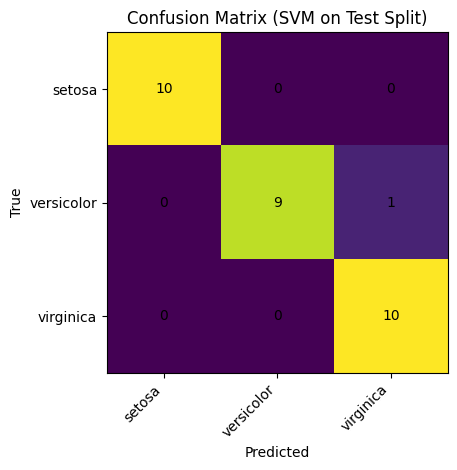

In [81]:
# 1) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 2) Standardize features 
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale  = scaler.transform(X_test)

# 3) Fit SVM (default SVC) 
svm = SVC()
svm.fit(X_train_scale, y_train)

# 4) Out-of-sample predictions 
predictions = svm.predict(X_test_scale)

# 5) Metrics & confusion matrix 
print("Classification report:")
print(classification_report(y_test, predictions, target_names=class_names, digits=3))

cm = confusion_matrix(y_test, predictions)
print("\nConfusion matrix:\n", cm)

# 6) Visualize confusion matrix
fig, ax = plt.subplots()
im = ax.imshow(cm)  
ax.set_title("Confusion Matrix (SVM on Test Split)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout(); plt.show()

In [82]:
# SVM Hyperparameter Tuning with GridSearchCV
k_features = X.shape[1]
param_grid = {
    "C":     [0.01, 0.1, 1, 10, 100],
    "gamma": [0.01/k_features, 0.1/k_features, "scale"]  
}

# 2) Use GridSearchCV to find best params on training set (optimize macro-F1)
grid = GridSearchCV(
    estimator=SVC(),          
    param_grid=param_grid,
    scoring="f1_macro",     # Use macro-F1 as optimization metric  
    cv=cv,                    
    n_jobs=1,
    return_train_score=True,
    refit=True                
)

grid.fit(X_train_scale, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV (macro-F1): {grid.best_score_:.4f}")

# 3) Evaluate tuned model on test set (compare with default SVM)
svm_best = grid.best_estimator_
y_pred_best = svm_best.predict(X_test_scale)

from sklearn.metrics import classification_report, confusion_matrix
print("\n[Tuned SVM] Test classification report:")
print(classification_report(y_test, y_pred_best, target_names=class_names, digits=3))
print("[Tuned SVM] Confusion matrix:\n", confusion_matrix(y_test, y_pred_best))

Best params: {'C': 100, 'gamma': 0.0025}
Best CV (macro-F1): 0.9833

[Tuned SVM] Test classification report:
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      1.000     0.900     0.947        10
   virginica      0.909     1.000     0.952        10

    accuracy                          0.967        30
   macro avg      0.970     0.967     0.967        30
weighted avg      0.970     0.967     0.967        30

[Tuned SVM] Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [83]:
# Final evaluation of tuned SVM on full dataset with cross-validation
X_scaled_full = StandardScaler().fit_transform(X)

# Evaluate tuned SVM with cross-validation on full dataset
svm_tuned_cv = cross_validate(
    estimator=grid.best_estimator_,  
    X=X_scaled_full,
    y=y,
    cv=cv,               
    scoring=scoring,   
    n_jobs=1
)

print(f"Tuned SVM mean Accuracy: {svm_tuned_cv['test_acc'].mean():.4f}")
print(f"Tuned SVM mean F1-macro: {svm_tuned_cv['test_f1_macro'].mean():.4f}")

Tuned SVM mean Accuracy: 0.9533
Tuned SVM mean F1-macro: 0.9532


## 5-2. Random Forest

- A Random Forest classification model was first built using default parameters,<br> with a fixed random seed to ensure reproducibility.
- Then, the model was evaluated using 5-fold cross-validation (StratifiedKFold), <br>calculating two performance metrics: accuracy and macro-averaged F1 score (macro-F1).
- Finally, the scores from each fold were summarized, and the mean and standard deviation were reported <br>to assess the model’s overall performance and stability across different data splits.

In [84]:
# 1) Build Random Forest model (default params; only set random seed for reproducibility)
rf = RandomForestClassifier(random_state=RANDOM_STATE)


In [85]:
# 2) Evaluate with cross-validation
cv_results_rf = cross_validate(
    estimator=rf,
    X=X,            
    y=y,
    cv=cv,           # StratifiedKFold(...)
    scoring=scoring, # {"acc":"accuracy", "f1_macro":"f1_macro"}
    return_train_score=False,
    n_jobs=1
)

# 3) Summarize results
rf_cv_acc_mean = cv_results_rf["test_acc"].mean()
rf_cv_f1_mean  = cv_results_rf["test_f1_macro"].mean()
rf_cv_acc_std  = cv_results_rf["test_acc"].std()
rf_cv_f1_std   = cv_results_rf["test_f1_macro"].std()

print("Random Forest — 5-fold CV results")
print("Accuracy per fold:",  np.round(cv_results_rf["test_acc"], 4))
print("Macro-F1 per fold:",  np.round(cv_results_rf["test_f1_macro"], 4))
print(f"\nMean Accuracy: {rf_cv_acc_mean:.4f}  (± {rf_cv_acc_std:.4f})")
print(f"Mean Macro-F1: {rf_cv_f1_mean:.4f}  (± {rf_cv_f1_std:.4f})")

Random Forest — 5-fold CV results
Accuracy per fold: [0.9667 0.9667 0.9333 0.9667 0.9   ]
Macro-F1 per fold: [0.9666 0.9666 0.9327 0.9666 0.8997]

Mean Accuracy: 0.9467  (± 0.0267)
Mean Macro-F1: 0.9464  (± 0.0268)


## 5-3. Neural Networks
- I built and trained a multilayer perceptron (MLP) neural network using TensorFlow (Keras)<br>
 to classify the standardized Iris dataset, <br>
 evaluating its performance on the test set with a confusion matrix and classification report.<br>
- Then, I applied 5-fold cross-validation using the SciKeras KerasClassifier wrapper, <br>
computing the mean Accuracy and Macro-F1 scores to assess the model’s overall generalization performance.

Neural Network (Keras) — hold-out report
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.889     0.800     0.842        10
   virginica      0.818     0.900     0.857        10

    accuracy                          0.900        30
   macro avg      0.902     0.900     0.900        30
weighted avg      0.902     0.900     0.900        30

Confusion matrix:
 [[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]


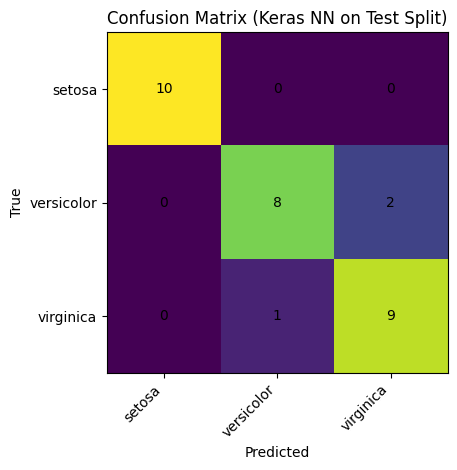

In [86]:
def build_model(input_dim, hidden_units=16, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_units, activation="relu"),
        layers.Dense(3, activation="softmax")   # Iris 三分类
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# 1) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# 2) Build Keras Neural Network model
model = Sequential([
    Input(shape=(X_train_s.shape[1],)),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')  # Iris三分类
])
model.compile(optimizer=Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3) Train model and evaluate on test set
model.fit(X_train_s, y_train, epochs=120, batch_size=16, validation_split=0.2, verbose=0)
y_pred = np.argmax(model.predict(X_test_s, verbose=0), axis=1)

print("Neural Network (Keras) — hold-out report")
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# 4) Visualize confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots()
im = ax.imshow(cm)
ax.set_title("Confusion Matrix (Keras NN on Test Split)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45
, ha="right")
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout(); plt.show()


In [87]:
# 1) Evaluate with cross-validation

nn_tf = KerasClassifier(
    model=build_model,
    input_dim=X.shape[1],
    hidden_units=16,
    lr=1e-3,
    epochs=120,
    batch_size=16,
    verbose=0,
    random_state=RANDOM_STATE
)

# 2) Summarize results
nn_cv_acc_mean = cv_results_nn["test_acc"].mean()
nn_cv_f1_mean  = cv_results_nn["test_f1_macro"].mean()
nn_cv_acc_std  = cv_results_nn["test_acc"].std()
nn_cv_f1_std   = cv_results_nn["test_f1_macro"].std()

print("\nNeural Network (MLP) — 5-fold CV results")
print("Accuracy per fold:",  np.round(cv_results_nn["test_acc"], 4))
print("Macro-F1 per fold:",  np.round(cv_results_nn["test_f1_macro"], 4))
print(f"\nMean Accuracy: {nn_cv_acc_mean:.4f}  (± {nn_cv_acc_std:.4f})")
print(f"Mean Macro-F1: {nn_cv_f1_mean:.4f}  (± {nn_cv_f1_std:.4f})")


Neural Network (MLP) — 5-fold CV results
Accuracy per fold: [1.     0.9667 0.8667 1.     0.9   ]
Macro-F1 per fold: [1.     0.9666 0.8682 1.     0.8997]

Mean Accuracy: 0.9467  (± 0.0542)
Mean Macro-F1: 0.9469  (± 0.0538)


## 5-4. Ridge
- For the fourth method, I chose Ridge Logistic Regression. <br>
- Ridge Logistic Regression is a variant of logistic regression <br>
that introduces an L2 regularization term to prevent overfitting and enhance model stability.
- I first standardized the Iris dataset and trained a multinomial logistic regression model<br>
 with an L2 penalty (penalty='l2'), generating a classification report and confusion matrix to evaluate its performance.<br>
- Then, I applied 5-fold cross-validation to compute the mean Accuracy and Macro-F1 scores, <br>
assessing the model’s overall generalization performance across different data splits.

Ridge Logistic Regression (hold-out) — classification report:
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.900     0.900     0.900        10
   virginica      0.900     0.900     0.900        10

    accuracy                          0.933        30
   macro avg      0.933     0.933     0.933        30
weighted avg      0.933     0.933     0.933        30

Ridge Logistic Regression (hold-out) — confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


/opt/anaconda3/envs/tf312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


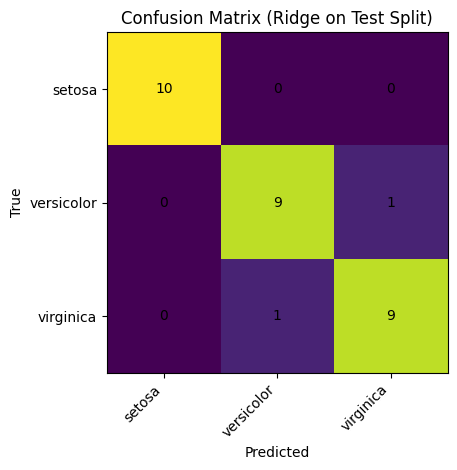

In [ ]:
# 1) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 2) Standardize features (for logistic regression)
scaler_lr = StandardScaler()
X_train_scale = scaler_lr.fit_transform(X_train)
X_test_scale  = scaler_lr.transform(X_test)

# 3) Fit Ridge Logistic Regression
ridge = LogisticRegression(
    multi_class='multinomial',
    solver='saga',     
    penalty='l2',      
    C=1.0,           
    random_state=RANDOM_STATE,
    max_iter=2000
)
ridge.fit(X_train_scale, y_train)

# 4) Predict on test set
y_pred = ridge.predict(X_test_scale)
print("Ridge Logistic Regression (hold-out) — classification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_test, y_pred)
print("Ridge Logistic Regression (hold-out) — confusion matrix:\n", cm)

# 5) Visualize confusion matrix
fig, ax = plt.subplots()
_ = ax.imshow(cm)
ax.set_title("Confusion Matrix (Ridge on Test Split)")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout(); plt.show()

In [ ]:
# 1) Evaluate Ridge Logistic Regression with cross-validation
X_scaled_full = StandardScaler().fit_transform(X)

cv_results_ridge = cross_validate(
    estimator=LogisticRegression(
        multi_class='multinomial',
        solver='saga',
        penalty='l2',
        C=1.0,
        random_state=RANDOM_STATE,
        max_iter=2000
    ),
    X=X_scaled_full,
    y=y,
    cv=cv,               
    scoring=scoring,     
    n_jobs=1
)

# 2) Summarize results
ridge_cv_acc_mean = cv_results_ridge["test_acc"].mean()
ridge_cv_f1_mean  = cv_results_ridge["test_f1_macro"].mean()
ridge_cv_acc_std  = cv_results_ridge["test_acc"].std()
ridge_cv_f1_std   = cv_results_ridge["test_f1_macro"].std()

print("\nRidge Logistic Regression — 5-fold CV results")
print("Accuracy per fold:",  np.round(cv_results_ridge["test_acc"], 4))
print("Macro-F1 per fold:",  np.round(cv_results_ridge["test_f1_macro"], 4))
print(f"\nMean Accuracy: {ridge_cv_acc_mean:.4f}  (± {ridge_cv_acc_std:.4f})")
print(f"Mean Macro-F1: {ridge_cv_f1_mean:.4f}  (± {ridge_cv_f1_std:.4f})")


Ridge Logistic Regression — 5-fold CV results
Accuracy per fold: [1.     0.9667 0.9    1.     0.9   ]
Macro-F1 per fold: [1.     0.9666 0.8997 1.     0.8997]

Mean Accuracy: 0.9533  (± 0.0452)
Mean Macro-F1: 0.9532  (± 0.0453)


/opt/anaconda3/envs/tf312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/tf312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/tf312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/tf312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: Futur

## 6. Compare
- I summarized and compared the 5-fold cross-validation results of the four models: <br>
the tuned SVM, Random Forest, Neural Network, and Ridge Logistic Regression.
- The mean Accuracy and Macro-F1 scores of each model were computed <br>
and visualized using a bar chart to clearly illustrate their overall performance differences.

,Accuracy,F1-macro
SVM_Tuned,0.9533,0.9532
RandomForest,0.9467,0.9464
NeuralNetwork,0.9467,0.9469
Ridge_LogReg,0.9533,0.9532


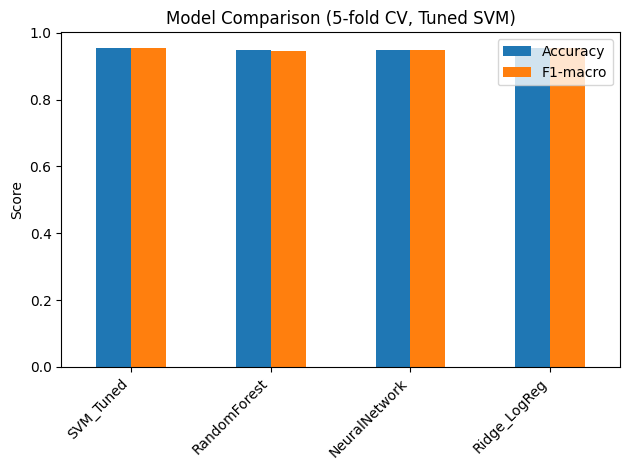

In [ ]:
# Summarize all models' CV results
cv_df = pd.DataFrame({
    "SVM_Tuned": {
        "Accuracy":  np.mean(svm_tuned_cv["test_acc"]),
        "F1-macro":  np.mean(svm_tuned_cv["test_f1_macro"])
    },
    "RandomForest": {
        "Accuracy":  np.mean(cv_results_rf["test_acc"]),
        "F1-macro":  np.mean(cv_results_rf["test_f1_macro"])
    },
    "NeuralNetwork": {
        "Accuracy":  np.mean(cv_results_nn["test_acc"]),
        "F1-macro":  np.mean(cv_results_nn["test_f1_macro"])
    },
    "Ridge_LogReg": {
        "Accuracy":  np.mean(cv_results_ridge["test_acc"]),
        "F1-macro":  np.mean(cv_results_ridge["test_f1_macro"])
    }
}).T

# 2) Display and plot results
display(cv_df.style.format("{:.4f}"))
cv_df.plot(kind="bar", title="Model Comparison (5-fold CV, Tuned SVM)")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Conclusion

<font size = "4">
Based on the 5-fold cross-validation results, all four models performed very similarly on the Iris dataset, <br>
with both accuracy and macro-F1 scores around 0.95.<br>
<br>
This suggests that the dataset has well-separated features and low noise, allowing different algorithms to learn the class boundaries effectively.
<br>
If one model must be recommended, SVM (Support Vector Machine) would be the preferred choice.<br>
It achieved slightly higher mean accuracy and macro-F1 in this experiment, while maintaining a simple structure, fast training speed, and stable performance on small datasets.


However, if model interpretability or scalability to larger datasets is a priority, <br>
Ridge Logistic Regression is also an excellent alternative, offering interpretability and low computational cost.


<br>
Overall, the four models achieved nearly identical predictive performance, <br>
but SVM performed slightly better and most consistently, making it the recommended model.